In [1]:
import pandas as pd
df = pd.read_csv('../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
print(df.shape)

(225745, 79)


In [2]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [4]:
df[' Label'].value_counts()

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

In [5]:
total_bytes = df['Total Length of Fwd Packets'] + df[' Total Length of Bwd Packets']

In [6]:
bin_size = 100
binned = total_bytes.groupby(total_bytes.index // bin_size).sum()

In [7]:
print(binned.shape)
binned.head(10)

(2258,)


0      49515
1    8929652
2    9872469
3    7953854
4      87899
5      20393
6      20658
7    4410105
8     186830
9      34934
dtype: int64

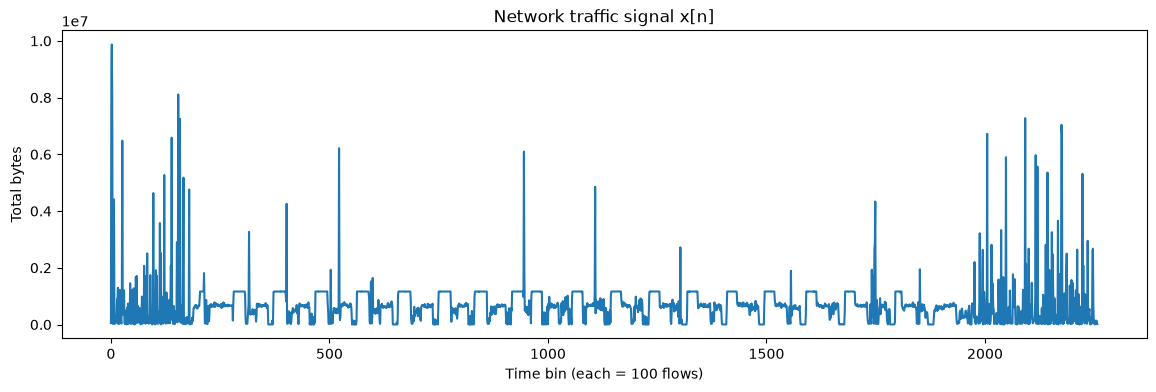

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,4)) 
plt.plot(binned.values) 
plt.xlabel('Time bin (each = 100 flows)') 
plt.ylabel('Total bytes') 
plt.title('Network traffic signal x[n]') 
plt.show()

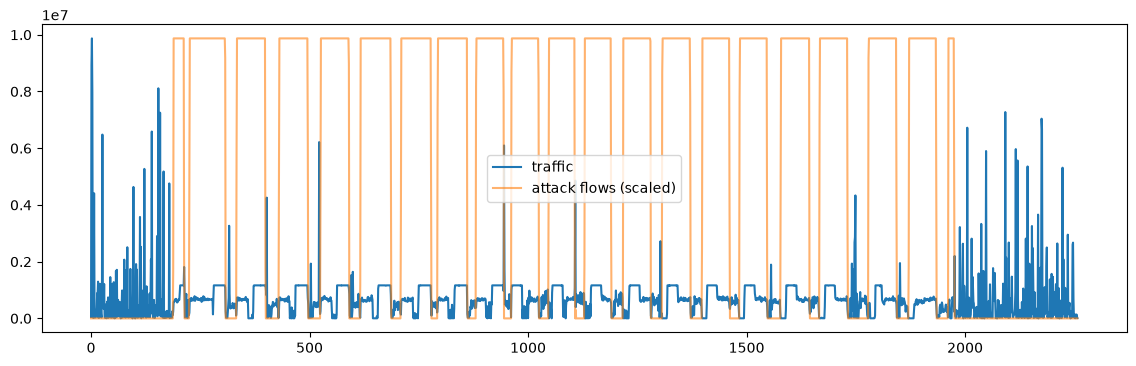

In [9]:
attack_mask = (df[' Label'] != 'BENIGN').groupby(df.index // bin_size).sum() 
plt.figure(figsize=(14,4)); 
plt.plot(binned.values, label='traffic'); 
plt.plot(attack_mask.values * (binned.max()/attack_mask.max()), label='attack flows (scaled)', alpha=0.6);
plt.legend(); 
plt.show()

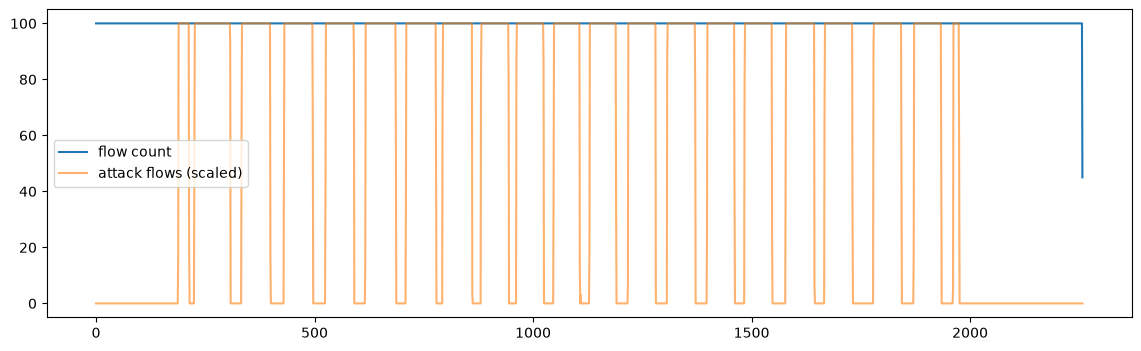

In [10]:
flow_count = df.groupby(df.index // bin_size).size()
plt.figure(figsize=(14,4))
plt.plot(flow_count.values, label='flow count')
plt.plot(attack_mask.values * (flow_count.max()/attack_mask.max()), label='attack flows (scaled)', alpha=0.6)
plt.legend()
plt.show()

In [13]:
packets = df[' Total Fwd Packets'] + df[' Total Backward Packets']
packet_signal = packets.groupby(df.index // bin_size).sum()
print(packet_signal.shape)

(2258,)


In [14]:
duration_signal = df[' Flow Duration'].groupby(df.index // bin_size).mean()
print(duration_signal.shape)

(2258,)


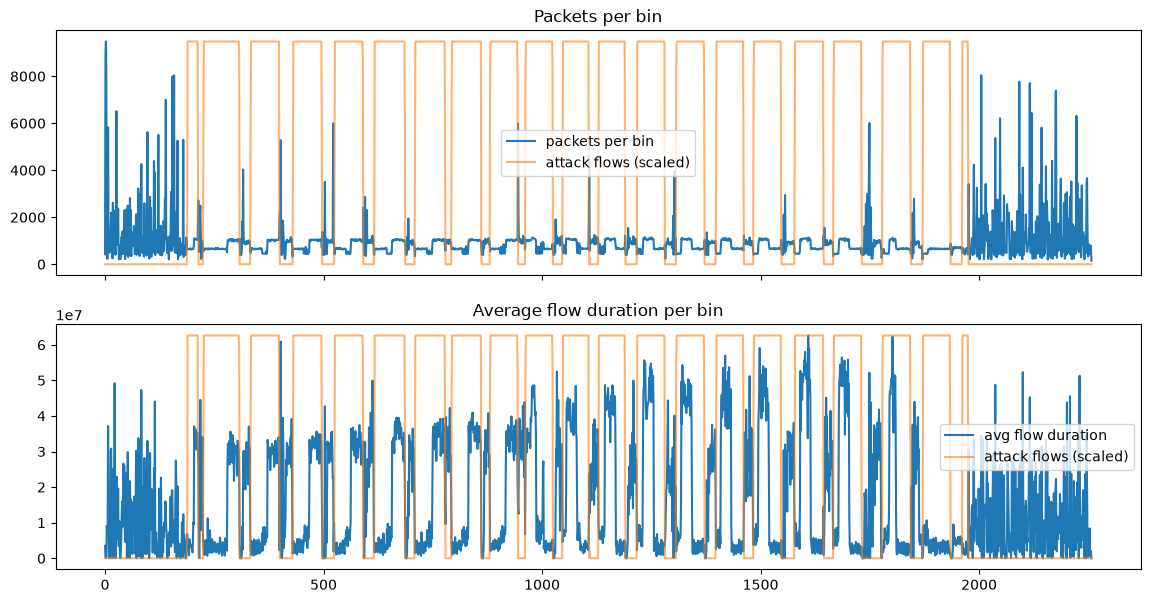

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(packet_signal.values, label='packets per bin')
axes[0].plot(attack_mask.values * (packet_signal.max() / attack_mask.max()), label='attack flows (scaled)', alpha=0.6)
axes[0].legend()
axes[0].set_title('Packets per bin')
axes[1].plot(duration_signal.values, label='avg flow duration')
axes[1].plot(attack_mask.values * (duration_signal.max() / attack_mask.max()), label='attack flows (scaled)', alpha=0.6)
axes[1].legend()
axes[1].set_title('Average flow duration per bin')
plt.show()

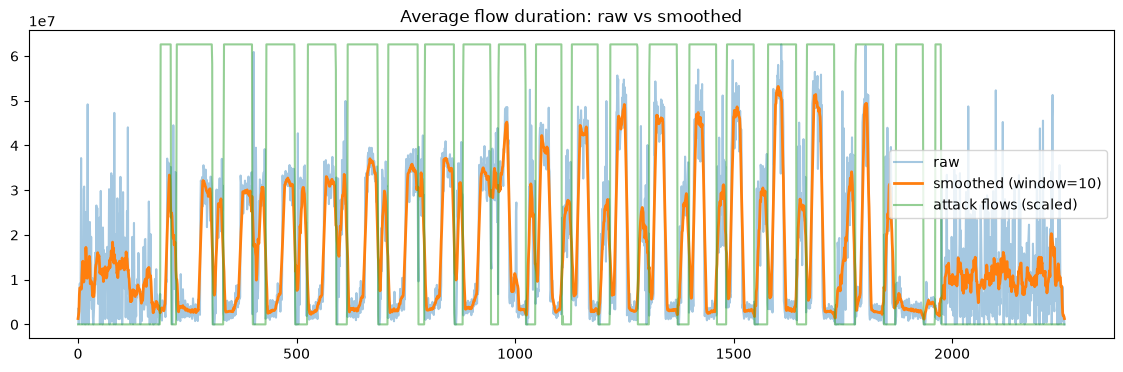

In [17]:
import numpy as np

signal = duration_signal.values
kernel = np.ones(10) / 10
smoothed = np.convolve(signal, kernel, mode='same')

plt.figure(figsize=(14, 4))
plt.plot(signal, label='raw', alpha=0.4)
plt.plot(smoothed, label='smoothed (window=10)', linewidth=2)
plt.plot(attack_mask.values * (signal.max() / attack_mask.max()), label='attack flows (scaled)', alpha=0.5)
plt.legend()
plt.title('Average flow duration: raw vs smoothed')
plt.show()